#Initial Boundary Value Problem Using PINNs
Our objective is to solve the following 1D heat conduction equation using PINNs:
\begin{align}
c\frac{\partial u}{\partial t} - \frac{\partial}{\partial x}\left(\kappa \frac{\partial u}{\partial x}\right)-p&=0,\ (x,t)\in \Omega \times \mathcal{T},\\
\kappa \frac{\partial u}{\partial x} &= h\ \text{on}\ \Gamma_N \times \mathcal{T},\\
u&=g\ \text{on}\ \Gamma_D\times \mathcal{T},\\
u(x,0)&=u_0\ \text{on}\ \Omega.
\end{align}
We consider the space-time domain $\Omega\times \mathcal{T}=[0,1]\times [0,0.5]$ with $\Gamma_D=\emptyset$ and $\Gamma_N=\{x\mid x=0, x=1\}$ with the Neumann boundary conditions $$\frac{\partial u}{\partial x}(0,t)=\frac{\partial u}{\partial x}(1,t)=0$$ and the intitial condition $$u(x,0)=u_0(x).$$
We assume temperature-dependent material properties:
\begin{align}
\text{heat capacity:}\ c(u)&=u^2/2000 + 500,\\
\text{thermal conductivity:}\ \kappa(u)&=u/100 + 7.
\end{align}
We will follow a *manufactured solution* given by

\begin{align}
u&=\exp\left(  -\frac{(x-s)^2}{2\sigma^2}  \right),\\
s(t) &= \frac{1}{4}\cos\left(\frac{2\pi t}{t_{\rm max}}\right) + \frac{1}{2}.
\end{align}
which implies the internal heat source
$$p=\frac{\kappa u}{\sigma^2} + u\frac{x-s}{\sigma^2}\left(c\frac{\partial s}{\partial t} - \frac{x-s}{\sigma^2}\left(\kappa + u\frac{\partial \kappa}{\partial u}\right)\right)$$
and the initial condition $$u_0=\exp\left(  -\frac{(x-\tfrac{3}{4})^2}{2\sigma^2}  \right)$$

This example is taken from the following reference:

L. Herrmann, et al., Deep Learning in Computational Mechanics: An Introductory Course. Cham: Springer Nature Switzerland, 2025.

Installing `equinox` (required in Colab):

In [ ]:
!pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.5 MB/s eta 0:00:00


Imports:

In [ ]:
import jax
import jax.numpy as jnp
import optax
import equinox as eqx
import matplotlib.pyplot as plt
from scipy.stats import qmc # quasi-Monte Carlo submodule

Defining the spatial & temporal domains:

In [ ]:
t_min, t_max = 0.0, 0.5
x_min, x_max = 0.0, 1.0

Analytical (manufactured) solution:

In [ ]:
sigma = 0.1 #Gaussian parameter
# Temperature
def Exact_Solution(t, x):
  s = 0.25 * jnp.cos(2 * jnp.pi * t / t_max) + 0.5
  u = jnp.exp(-(x - s)**2/(2*sigma**2))
  return u

Visualizing the exact solution:

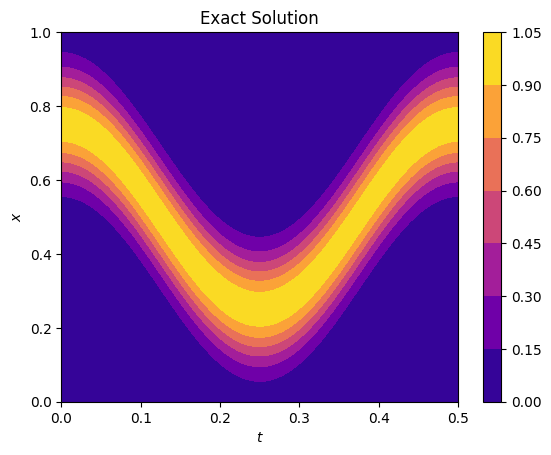

In [ ]:
x_grid = jnp.linspace(x_min, x_max, 100)
t_grid = jnp.linspace(t_min, t_max, 100)
T_grid, X_grid = jnp.meshgrid(t_grid, x_grid)
U_exat = Exact_Solution(T_grid, X_grid)

plt.figure()
plt.contourf(T_grid, X_grid, U_exat, cmap='plasma')
plt.colorbar()
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.title(r"Exact Solution")
plt.show()

Material Properties:

In [ ]:
def Material_Properties(u):
  c = u**2/2000 + 500.0
  kappa = u/100 + 7.0
  return c, kappa

The internal heat source term that follows from the manufactured solution:

In [ ]:
def internal_source(t, x):
  u = Exact_Solution(t, x)
  c, kappa = Material_Properties(u)
  dkappa_du = 0.01
  s = 0.25 * jnp.cos(2 * jnp.pi * t / t_max) + 0.5
  ds_dt = -0.25 * (2 * jnp.pi / t_max) * jnp.sin(2 * jnp.pi * t / t_max)
  p = kappa * u / sigma**2 + (u/sigma**2) * (x - s) * ( c * ds_dt -  ((x - s)/sigma**2) * (kappa + u * dkappa_du))
  return p

Exact heat flux for comparison purposes:

In [ ]:
# Heat flux
def Exact_Flux(t, x):
  u = Exact_Solution(t,x)
  _, kappa = Material_Properties(u)
  s = 0.25 * jnp.cos(2 * jnp.pi * t / t_max) + 0.5
  du_dx = -(x - s) * u / sigma**2
  return -kappa * du_dx

##PINN

Generating keys for randomizing the initial weights:

In [ ]:
key = jax.random.PRNGKey(42)
key, init_key = jax.random.split(key)

We now define the PINN that approximates the solution: $$u(t,x)\approx {\rm NN}(t,x;\theta)$$

In [ ]:
pinn = eqx.nn.MLP(
    in_size=2,
    out_size='scalar',
    width_size=10,
    depth=3,
    activation=jax.nn.tanh,
    key=init_key,
)

Wrapping up the PINN as a function of $(t,x)$:

In [ ]:
def pinn_hat(network,t,x):
  return network(jnp.array([t,x]))

In [ ]:
pinn_hat(pinn,0.1,0.2)

Array(0.11909792, dtype=float32)

Visualizing the initial PINN approximation:

(10000, 2)
(10000,)


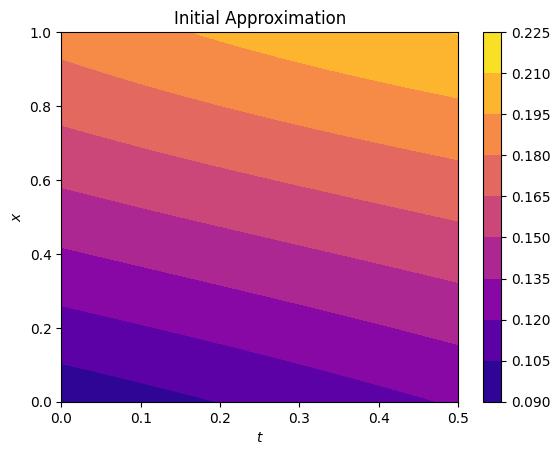

In [ ]:
TX_grid = jnp.stack([T_grid.ravel(), X_grid.ravel()], axis=1)
print(TX_grid.shape)

U_initial = jax.vmap(pinn)(TX_grid)
print(U_initial.shape)
plt.figure()
plt.contourf(T_grid, X_grid, U_initial.reshape(100,100),cmap='plasma')
plt.colorbar()
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.title(r"Initial Approximation")
plt.show()


We define a function that calculates the heat flux $q=-\kappa \frac{\partial u}{\partial x}$:

In [ ]:
def Heat_Flux(network, t, x):
  u = pinn_hat(network, t, x)
  _, kappa = Material_Properties(u)
  q = -kappa * jax.grad(pinn_hat, argnums=2)(network,t,x)
  return q

In [ ]:
Heat_Flux(pinn, 0.1, 0.2)

Array(-0.66848415, dtype=float32)

##PDE Residual

In [ ]:
def PDE_residual(network, t, x):
  u = pinn_hat(network, t, x)
  c, _ = Material_Properties(u)
  u_t = jax.grad(pinn_hat, argnums=1)(network,t,x)
  q_x = jax.grad(Heat_Flux, argnums=2)(network,t,x)
  p = internal_source(t,x)
  r = c *  u_t + q_x - p
  return r

In [ ]:
PDE_residual(pinn, 0.1, 0.1)

Array(24.149895, dtype=float32)

Let's plot the initial PDE residual:

In [ ]:
init_PDE_residual = jax.vmap(PDE_residual, in_axes=(None,0,0))(pinn, TX_grid[:,0], TX_grid[:,1])

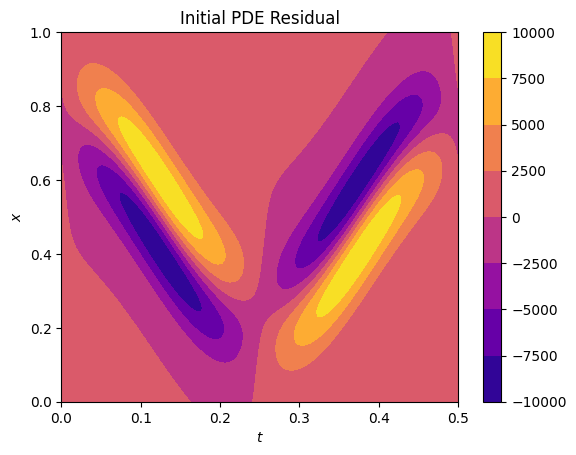

In [ ]:
plt.figure()
plt.contourf(T_grid, X_grid, init_PDE_residual.reshape(100,100),cmap='plasma')
plt.colorbar()
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.title(r"Initial PDE Residual")
plt.show()

Collocation points across both time and space for PDE loss; we use the *Latin-Hypercube Sampling (LHS)* method:

In [ ]:
key, collocation_key = jax.random.split(key)
N_collocations = 200
sampler = qmc.LatinHypercube(d=2, seed=int(collocation_key[0]))
samples = sampler.random(n=N_collocations)
collocation_points = qmc.scale(samples,[t_min,x_min],[t_max,x_max])
collocation_points.shape

(200, 2)

We define a function that returns the $L_2$ PDE loss of a network over the collocation points:

In [ ]:
def PDE_Loss(network):
  r_pde = jax.vmap(PDE_residual, in_axes=(None,0,0))(network, collocation_points[:,0], collocation_points[:,1])
  return jnp.mean(r_pde**2)

In [ ]:
print(PDE_Loss(pinn))

10461412.0


##Boundary Conditions
We enforce the homogeneous Neumann B.Cs at both end $x=0$ and $x=1$ across a set of temporal collocation points:

In [ ]:
key, bc_key = jax.random.split(key)
Nt_collocation = 20
t_collocation = jax.random.uniform(bc_key, (Nt_collocation,), minval=t_min, maxval=t_max)

def BC_Loss(network):
  qx_0 = jax.vmap(Heat_Flux, in_axes=(None,0,None))(network, t_collocation, x_min)
  qx_1 = jax.vmap(Heat_Flux, in_axes=(None,0,None))(network, t_collocation, x_max)
  return jnp.mean(qx_0**2) + jnp.mean(qx_1**2)

In [ ]:
BC_Loss(pinn)

Array(0.7439787, dtype=float32)

##Initial Conditions
We enforce the initial condition $u(0,x)=u_{\rm exact}(0,x)$ across a set of spatial collocation points:

In [ ]:
key, ic_key = jax.random.split(key)
Nx_collocation = 60
x_collocation = jax.random.uniform(ic_key, (Nx_collocation,), minval=x_min, maxval=x_max)


def IC_Loss(network):
  u0_pinn = jax.vmap(pinn_hat, in_axes=(None,None,0))(network, t_min, x_collocation)
  u0_exact = Exact_Solution(t_min, x_collocation)
  return jnp.mean((u0_pinn - u0_exact)**2)

In [ ]:
IC_Loss(pinn)

Array(0.15332729, dtype=float32)

##Total loss function:

In [ ]:
L0_PDE = PDE_Loss(pinn)
L0_BC = BC_Loss(pinn)
L0_IC = IC_Loss(pinn)
eps0 = 1e-12
lambda_PDE = 1.0 / (L0_PDE + eps0)
lambda_BC = 1.0 / (L0_BC + eps0)
lambda_IC = 1.0 / (L0_IC + eps0)

def Total_Loss(network):
  # return PDE_Loss(network) + BC_Loss(network) + IC_Loss(network)
  return lambda_PDE * PDE_Loss(network) + lambda_BC * BC_Loss(network) + lambda_IC *IC_Loss(network)

In [ ]:
Total_Loss(pinn)

Array(3., dtype=float32)

##Training
We set up an optimizer in `optax`:

In [ ]:
optimizer = optax.adam(learning_rate=1e-3)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))

We define a `Make_Step` function that will perform the updates at each training epoch:

In [ ]:
@eqx.filter_jit
def Make_Step(network, state):
  loss, grads = eqx.filter_value_and_grad(Total_Loss)(network)
  updates, new_state = optimizer.update(grads, state)
  new_network = eqx.apply_updates(network, updates)
  return new_network, new_state, loss

Training loop:

In [ ]:
N_epochs = 15_000 #no. of epochs
loss_history = []
PDE_loss_history = []
BC_loss_history = []
IC_loss_history = []

for epoch in range(N_epochs):
  pinn, opt_state, loss = Make_Step(pinn, opt_state)
  loss_history.append(loss)

  if epoch % 1000 == 0:
    print(f"Epoch: {epoch}, Loss: {loss}")
    PDE_loss_history.append(PDE_Loss(pinn))
    BC_loss_history.append(BC_Loss(pinn))
    IC_loss_history.append(IC_Loss(pinn))

Epoch: 0, Loss: 3.0
Epoch: 1000, Loss: 1.5461229085922241
Epoch: 2000, Loss: 1.274667739868164
Epoch: 3000, Loss: 0.8305512070655823
Epoch: 4000, Loss: 0.5580217242240906
Epoch: 5000, Loss: 0.10715752094984055
Epoch: 6000, Loss: 0.05100804939866066
Epoch: 7000, Loss: 0.032562050968408585
Epoch: 8000, Loss: 0.02414240501821041
Epoch: 9000, Loss: 0.018816692754626274
Epoch: 10000, Loss: 0.0147193418815732
Epoch: 11000, Loss: 0.01130656711757183
Epoch: 12000, Loss: 0.008988636545836926
Epoch: 13000, Loss: 0.007433955557644367
Epoch: 14000, Loss: 0.0064508551731705666


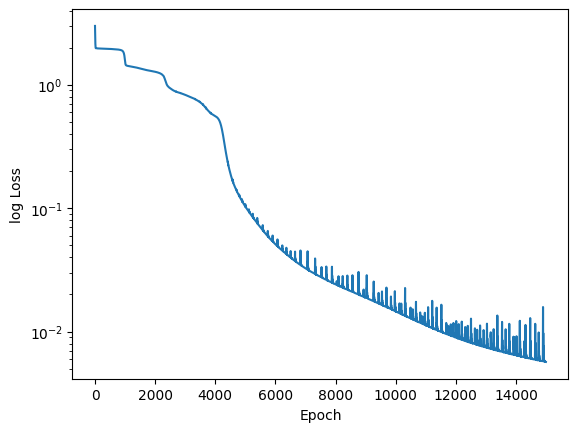

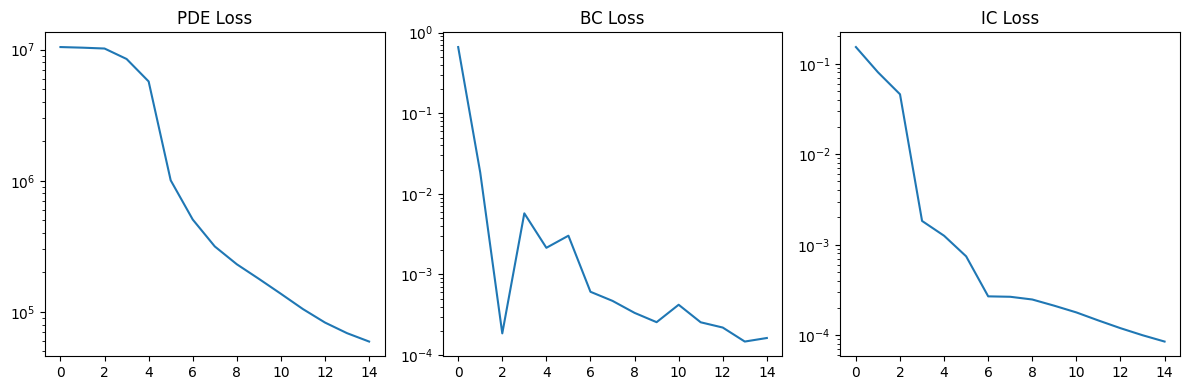

In [ ]:
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("log Loss")
plt.show()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(PDE_loss_history)
plt.yscale('log')
plt.title('PDE Loss')
plt.subplot(1,3,2)
plt.plot(BC_loss_history)
plt.yscale('log')
plt.title('BC Loss')
plt.subplot(1,3,3)
plt.plot(IC_loss_history)
plt.yscale('log')
plt.title('IC Loss')
plt.tight_layout()
plt.show()

##Results
Visualizing the PINN solution:

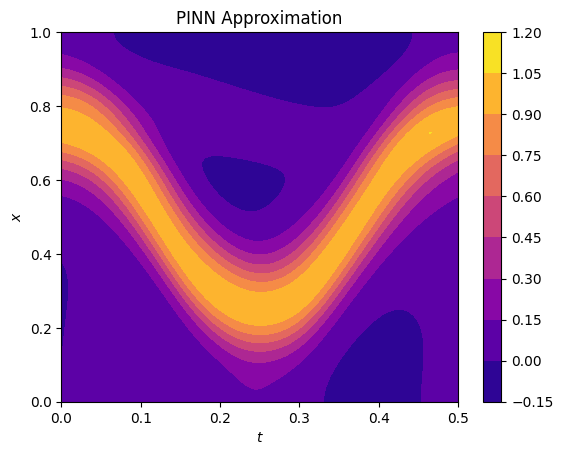

In [ ]:
U_pinn = jax.vmap(pinn)(TX_grid)
plt.figure()
plt.contourf(T_grid, X_grid, U_pinn.reshape(100,100),cmap='plasma')
plt.colorbar()
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.title(r"PINN Approximation")
plt.show()

Let's examine approximation error at particular time instants:

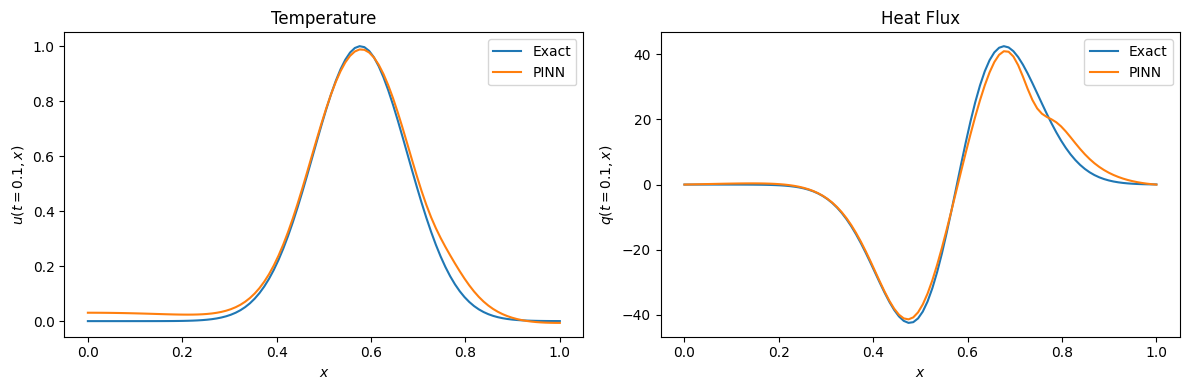

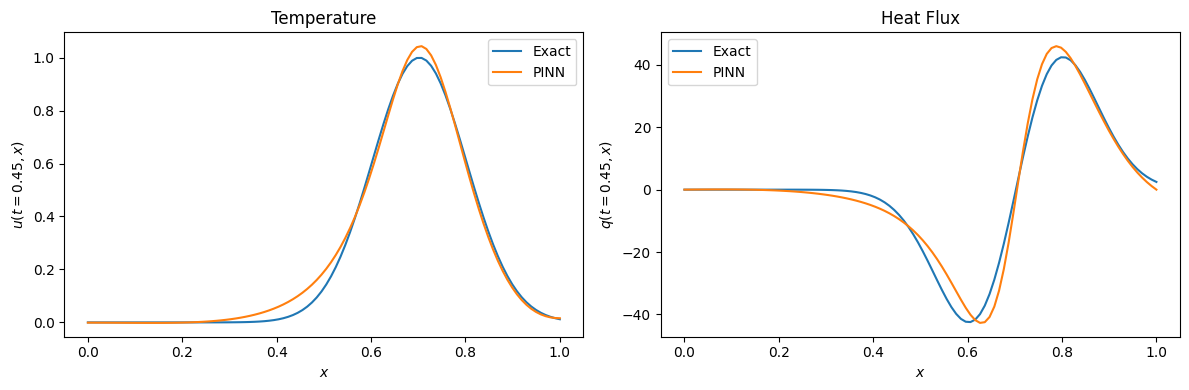

In [ ]:
t_instant = 0.1
# Temperature
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_grid, Exact_Solution(t_instant, x_grid), label='Exact')
plt.plot(x_grid, jax.vmap(pinn_hat, in_axes=(None,None,0))(pinn, t_instant, x_grid), label='PINN')
plt.legend()
plt.xlabel(r"$x$")
plt.ylabel(r"$u(t=0.1,x)$")
plt.title(r"Temperature")

# Heat flux
plt.subplot(1,2,2)
plt.plot(x_grid, Exact_Flux(t_instant, x_grid), label='Exact')
plt.plot(x_grid, jax.vmap(Heat_Flux, in_axes=(None,None,0))(pinn, t_instant, x_grid), label='PINN')
plt.legend()
plt.xlabel(r"$x$")
plt.ylabel(r"$q(t=0.1,x)$")
plt.title(r"Heat Flux")
plt.tight_layout()
plt.show()

t_instant = 0.45
# Temperature
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_grid, Exact_Solution(t_instant, x_grid), label='Exact')
plt.plot(x_grid, jax.vmap(pinn_hat, in_axes=(None,None,0))(pinn, t_instant, x_grid), label='PINN')
plt.legend()
plt.xlabel(r"$x$")
plt.ylabel(r"$u(t=0.45,x)$")
plt.title(r"Temperature")

# Heat flux
plt.subplot(1,2,2)
plt.plot(x_grid, Exact_Flux(t_instant, x_grid), label='Exact')
plt.plot(x_grid, jax.vmap(Heat_Flux, in_axes=(None,None,0))(pinn, t_instant, x_grid), label='PINN')
plt.legend()
plt.xlabel(r"$x$")
plt.ylabel(r"$q(t=0.45,x)$")
plt.title(r"Heat Flux")
plt.tight_layout()
plt.show()